# Holdout validation

In [1]:
from pathlib import Path
from typing import Any

import pandas as pd

from config import PlotConfig
from filters import (
    filter_artificial_missing_entries,
    filter_tissue_entries,
)
from metrics import compute_metrics
from plots import plot_metric
from utils import extract_miss_level

In [2]:
MODEL_DIRECTORY_REGISTRY = {
    "protogain_dir": "ProtoGain",
    "tissue_mean_dir": "Tissue Mean",
    "global_mean_dir": "Mean",
    "missforest_dir": "MissForest",
    "autoencoder_dir": "AutoEncoder"
}

def _get_model_configs_from_dict(kwargs_dict: dict[str, Any]) -> list[tuple[Path, str]]:
    valid_configs = []
    
    for key, model_name in MODEL_DIRECTORY_REGISTRY.items():
        user_input = kwargs_dict.get(key)
        if user_input is None:
            continue
            
        try:
            path_obj = Path(user_input)
            if path_obj.is_dir():
                valid_configs.append((path_obj, model_name))
        except (TypeError, ValueError):
            continue
            
    return valid_configs

In [3]:
def _add_model_markers(df: pd.DataFrame) -> pd.DataFrame:
    if df.empty:
        return df
    marker_map = PlotConfig().marker_map
    markers = df["Model"].map(marker_map).fillna("")
    df["Model (Marker)"] = df["Model"] + " (" + markers + ")"
    return df

In [4]:
def _iter_predictions(model_dir: Path) -> tuple[Path, pd.DataFrame]:
    """Yields valid run directories and their loaded predictions DataFrames."""
    runs = []
    for run_dir in model_dir.iterdir():
        if not run_dir.is_dir():
            continue
        pred_path = run_dir / "predictions" / "predictions.csv"
        if pred_path.exists():
            runs.append([run_dir, pd.read_csv(pred_path)])
    return runs

In [5]:
def collect_tissue_predictions(model_dir: Path, model_name: str) -> list[dict]:
    """Collect per-tissue predictions."""
    rows = []
    miss_level = extract_miss_level(model_dir)
    
    for _, predictions in _iter_predictions(model_dir):
        for tissue in predictions["group_id"].unique():
            tissue_entries = filter_tissue_entries(predictions=predictions, tissue=tissue)
            
            rows.append({
                "True values": tissue_entries["true_value"].to_numpy(dtype=float),
                "Predicted values": tissue_entries["predicted_value"].to_numpy(dtype=float),
                "Tissue": tissue,
                "Number of samples": tissue_entries["sample_id"].nunique(),
                "Missing level": miss_level,
                "Model": model_name,
            })
    return rows

In [6]:
def collect_metrics(miss_dir: Path, model_name: str) -> list[dict]:
    """Collect Pearson r and RMSE performance statistics."""
    rows = []
    miss_level = extract_miss_level(miss_dir)
    
    for _, predictions in _iter_predictions(miss_dir):
        missing_entries = filter_artificial_missing_entries(predictions=predictions)
        true_vals = missing_entries["true_value"].to_numpy(dtype=float)
        pred_vals = missing_entries["predicted_value"].to_numpy(dtype=float)
        
        r, rmse = compute_metrics(true_vals, pred_vals)
        rows.append({
            "Model": model_name,
            "Pearson r": r,
            "RMSE": rmse,
            "Number of samples": missing_entries["sample_id"].nunique(),
            "Missing level": miss_level,
        })
    return rows

In [7]:
def build_tissue_predictions(**kwargs) -> pd.DataFrame:
    """Aggregate predictions (only artificial missing entries) from all models into a single DataFrame."""
    rows = []
    configs = _get_model_configs_from_dict(kwargs)
    for folder, name in configs:
        rows.extend(collect_tissue_predictions(model_dir=folder, model_name=name))
        
    return _add_model_markers(pd.DataFrame(rows))


def build_performance(**kwargs) -> pd.DataFrame:
    """Aggregate Pearson and RMSE from all models into a single DataFrame."""
    rows = []
    configs = _get_model_configs_from_dict(kwargs)
    for folder, name in configs:
        rows.extend(collect_metrics(miss_dir=folder, model_name=name))
        
    return _add_model_markers(pd.DataFrame(rows))

---
# Analysis — missing level 10%

In [8]:
global_mean_dir = Path("../../experiments/benchmark/PXD030304_no_control_multi_peptide_50pct_tissue_transpose/benchmark_2026-05-27_16:43:57/global_mean/miss_10")
autoencoder_dir = Path("../../experiments/benchmark/PXD030304_no_control_multi_peptide_50pct_tissue_transpose/benchmark_2026-05-27_17:00:23/autoencoder/miss_10")

kwargs = {
    "global_mean_dir": global_mean_dir,
    "autoencoder_dir": autoencoder_dir,
}

# Guarantee that the evaluation is performed on the same missing level
unique_miss_levels = {
    extract_miss_level(d) 
    for d in kwargs.values() 
    if d is not None and extract_miss_level(d) is not None
}

if len(unique_miss_levels) > 1:
    raise ValueError(
        f"Mismatched missing levels detected across models! Found: {sorted(list(unique_miss_levels))}. "
        f"All models must be evaluated on the same missing level percentage."
    )
elif len(unique_miss_levels) == 0:
    raise ValueError("Could not extract a valid missing level from any of the provided paths.")

miss_level = unique_miss_levels.pop()

In [9]:
plot_dir = Path(f"./plots/holdout/miss_{miss_level}")
plot_dir.mkdir(parents=True, exist_ok=True)

In [10]:
# tissue_predictions = build_tissue_predictions(**kwargs)
performance = build_performance(**kwargs)

Saved: plots/holdout/miss_10/pearson_r_by_model_miss10.png
Saved: plots/holdout/miss_10/rmse_by_model_miss10.png


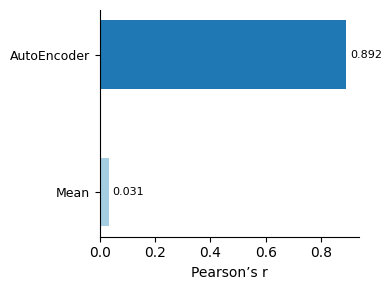

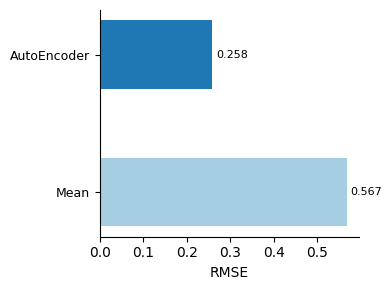

In [11]:
plot_metric(
    performance,
    metric="Pearson r",
    miss_level=miss_level,
    plot_dir=plot_dir,
    figsize=(4, 3),
)

plot_metric(
    performance,
    metric="RMSE",
    miss_level=miss_level,
    plot_dir=plot_dir,
    figsize=(4, 3),
)